# Stock Market Prediction — Linear Regression
**Dataset:** Stock Market Data (2019–2024) | 5 Companies | 7,825 Records

**Goal:** Predict the closing price using other financial indicators with Linear Regression

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Dataset

In [2]:
df = pd.read_csv('Stock_Market_Dataset.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (7825, 8)


,Date,Company,Open,High,Low,Close,Volume,Adj_Close
0,2019-01-02,AAPL,150.73,151.64,150.21,151.39,54463210,150.67
1,2019-01-02,AMZN,132.87,133.87,131.73,131.85,65141294,131.81
2,2019-01-02,GOOGL,102.24,103.28,101.39,102.27,26381236,102.25
3,2019-01-02,MSFT,227.67,228.59,225.63,226.31,41024360,225.74
4,2019-01-02,TSLA,202.69,203.65,201.34,201.97,189249672,201.94
5,2019-01-03,AAPL,155.10,156.10,153.70,155.58,34964167,155.56
6,2019-01-03,AMZN,131.67,133.25,130.67,132.14,111170825,131.94
7,2019-01-03,GOOGL,104.93,105.63,104.14,105.20,50243630,104.92
8,2019-01-03,MSFT,223.67,225.71,221.32,224.39,47204385,223.30
9,2019-01-03,TSLA,203.57,205.43,202.59,204.15,170512195,203.39


## 3. Basic Info & Statistics

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7825 entries, 0 to 7824
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       7825 non-null   str    
 1   Company    7825 non-null   str    
 2   Open       7825 non-null   float64
 3   High       7825 non-null   float64
 4   Low        7825 non-null   float64
 5   Close      7825 non-null   float64
 6   Volume     7825 non-null   int64  
 7   Adj_Close  7825 non-null   float64
dtypes: float64(5), int64(1), str(2)
memory usage: 489.2 KB


In [4]:
df.describe().round(2)

,Open,High,Low,Close,Volume,Adj_Close
count,7825.00,7825.00,7825.00,7825.00,7.825000e+03,7825.00
mean,158.61,160.13,157.08,158.64,7.245451e+07,158.24
std,83.81,84.63,83.02,83.84,4.624358e+07,83.64
min,27.97,28.47,27.66,28.09,1.000710e+07,27.99
25%,102.17,103.20,101.19,102.25,3.744610e+07,101.98
50%,133.38,134.65,132.16,133.23,5.659215e+07,132.91
75%,213.32,215.16,210.81,213.34,1.028816e+08,212.76
max,433.19,438.89,430.56,431.18,1.979955e+08,429.69


In [5]:
# checking null values
print('Missing values:')
print(df.isnull().sum())
print('\nTotal missing:', df.isnull().sum().sum())

Missing values:
Date         0
Company      0
Open         0
High         0
Low          0
Close        0
Volume       0
Adj_Close    0
dtype: int64

Total missing: 0


In [6]:
# checking duplicates
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [7]:
# how many records per company
print('Records per company:')
print(df['Company'].value_counts())

Records per company:
Company
AAPL     1565
AMZN     1565
GOOGL    1565
MSFT     1565
TSLA     1565
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

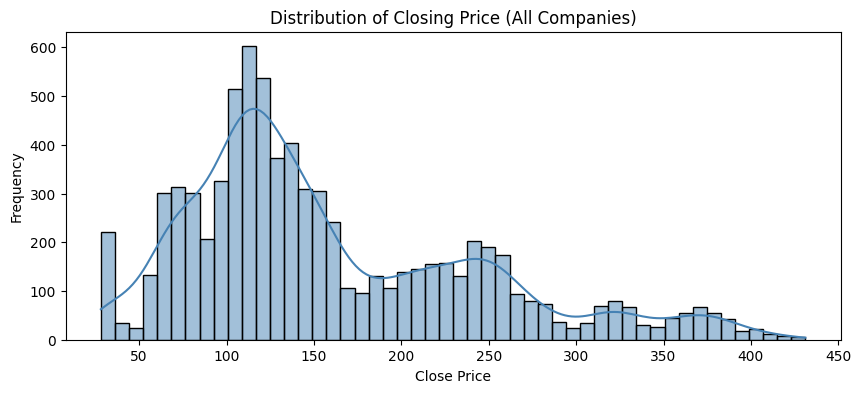

In [8]:
# distribution of closing price
plt.figure(figsize=(10, 4))
sns.histplot(df['Close'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Closing Price (All Companies)')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.show()

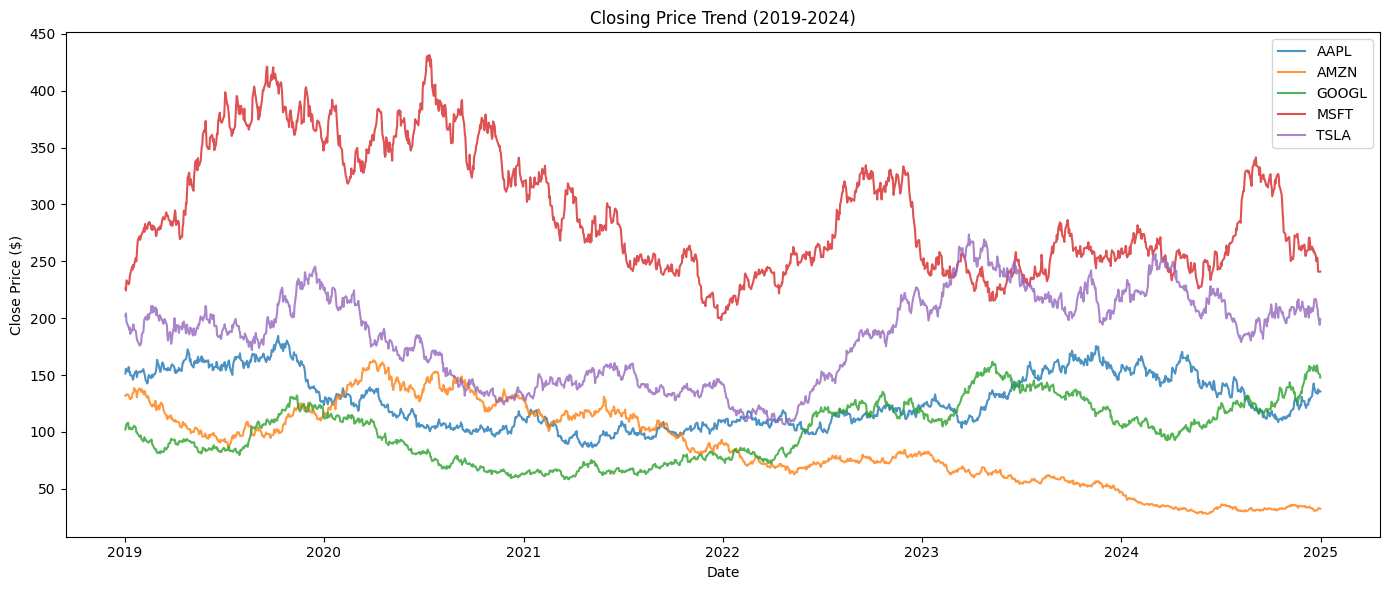

In [9]:
# closing price trend over time for each company
df['Date'] = pd.to_datetime(df['Date'])

plt.figure(figsize=(14, 6))
for company in df['Company'].unique():
    temp = df[df['Company'] == company]
    plt.plot(temp['Date'], temp['Close'], label=company, alpha=0.8)

plt.title('Closing Price Trend (2019-2024)')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

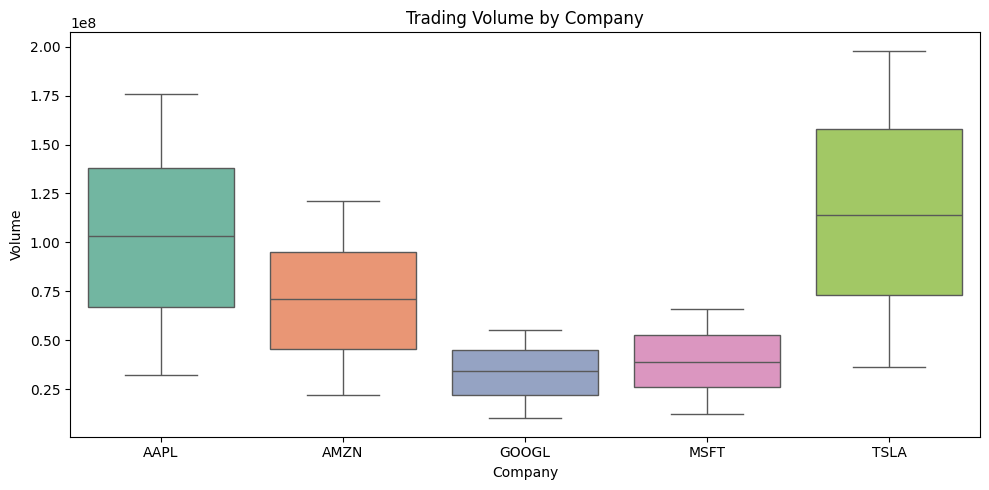

In [10]:
# volume comparison across companies
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Company', y='Volume', palette='Set2')
plt.title('Trading Volume by Company')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

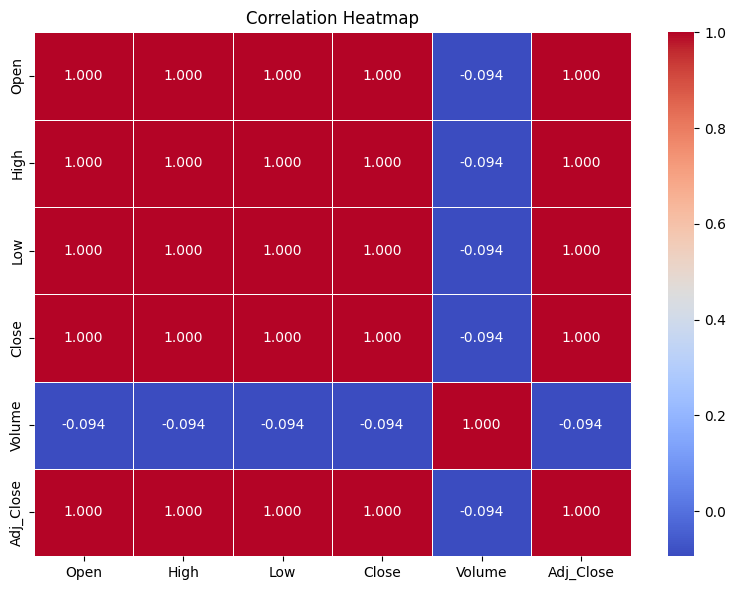

In [11]:
# correlation heatmap for numeric columns
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Adj_Close']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

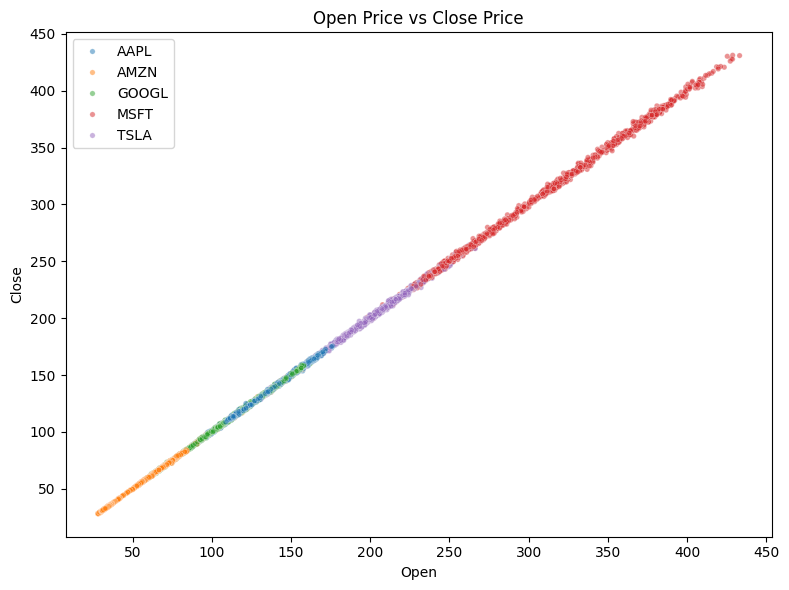

In [12]:
# scatter plot: Open vs Close
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Open', y='Close', hue='Company', alpha=0.5, s=15)
plt.title('Open Price vs Close Price')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

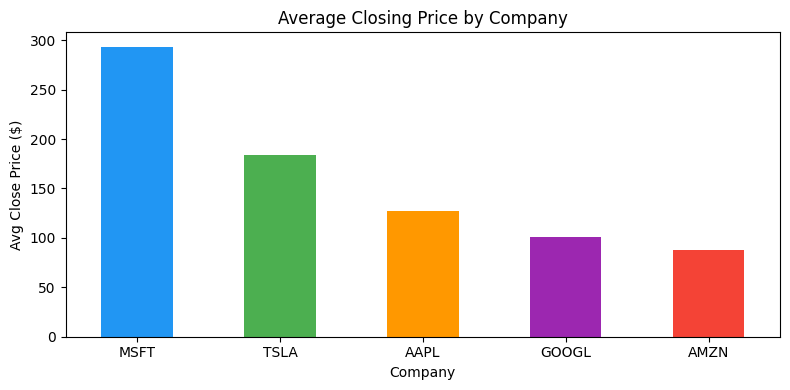

In [13]:
# average closing price per company
avg_close = df.groupby('Company')['Close'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
avg_close.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336'])
plt.title('Average Closing Price by Company')
plt.ylabel('Avg Close Price ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

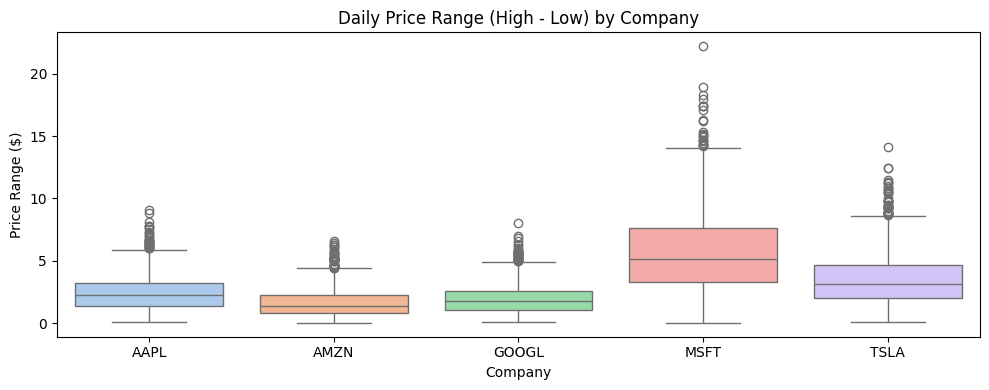

In [14]:
# daily price range (High - Low)
df['Price_Range'] = df['High'] - df['Low']

plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Company', y='Price_Range', palette='pastel')
plt.title('Daily Price Range (High - Low) by Company')
plt.ylabel('Price Range ($)')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [15]:
# creating some extra features that might help the model
df['Price_Range'] = df['High'] - df['Low']       # already created above
df['Price_Change'] = df['Close'] - df['Open']    # daily change
df['Avg_Price'] = (df['High'] + df['Low']) / 2   # average of high and low

print('New features added!')
df[['Open', 'High', 'Low', 'Close', 'Price_Range', 'Price_Change', 'Avg_Price']].head()

New features added!


,Open,High,Low,Close,Price_Range,Price_Change,Avg_Price
0,150.73,151.64,150.21,151.39,1.43,0.66,150.925
1,132.87,133.87,131.73,131.85,2.14,-1.02,132.800
2,102.24,103.28,101.39,102.27,1.89,0.03,102.335
3,227.67,228.59,225.63,226.31,2.96,-1.36,227.110
4,202.69,203.65,201.34,201.97,2.31,-0.72,202.495


In [16]:
# encoding company name to numbers
le = LabelEncoder()
df['Company_Encoded'] = le.fit_transform(df['Company'])

print('Company encoding:')
for i, comp in enumerate(le.classes_):
    print(f'  {comp} -> {i}')

Company encoding:
  AAPL -> 0
  AMZN -> 1
  GOOGL -> 2
  MSFT -> 3
  TSLA -> 4


## 6. Data Preprocessing

In [17]:
# selecting features and target
feature_cols = ['Open', 'High', 'Low', 'Volume', 'Adj_Close',
                'Price_Range', 'Price_Change', 'Avg_Price', 'Company_Encoded']

X = df[feature_cols]
y = df['Close']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (7825, 9)
Target shape: (7825,)


In [18]:
# scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled.head()

,Open,High,Low,Volume,Adj_Close,Price_Range,Price_Change,Avg_Price,Company_Encoded
0,-0.094074,-0.100344,-0.082745,-0.389080,-0.090542,-0.669450,0.627278,-0.091634,-1.414214
1,-0.307182,-0.310338,-0.305366,-0.158156,-0.316051,-0.376493,-1.026911,-0.307894,-0.707107
2,-0.672663,-0.671830,-0.670858,-0.996381,-0.669500,-0.479647,0.006957,-0.671388,0.000000
3,0.823985,0.809001,0.825807,-0.679709,0.807069,-0.038148,-1.361688,0.817371,0.707107
4,0.525920,0.514276,0.533196,2.525813,0.522493,-0.306348,-0.731520,0.523676,1.414214


In [19]:
# splitting into train and test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print('Training set:', X_train.shape)
print('Testing set:', X_test.shape)

Training set: (6260, 9)
Testing set: (1565, 9)


## 7. Model Training — Linear Regression

In [20]:
# training the model
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained!')
print('Intercept:', round(model.intercept_, 4))

Model trained!
Intercept: 158.637


In [21]:
# checking which features matter most
coeff_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_.round(4)
}).sort_values('Coefficient', ascending=False)

print('Feature Coefficients:')
coeff_df

Feature Coefficients:


,Feature,Coefficient
0,Open,83.8073
6,Price_Change,1.0156
1,High,0.0000
3,Volume,0.0000
2,Low,0.0000
4,Adj_Close,0.0000
5,Price_Range,0.0000
7,Avg_Price,0.0000
8,Company_Encoded,0.0000


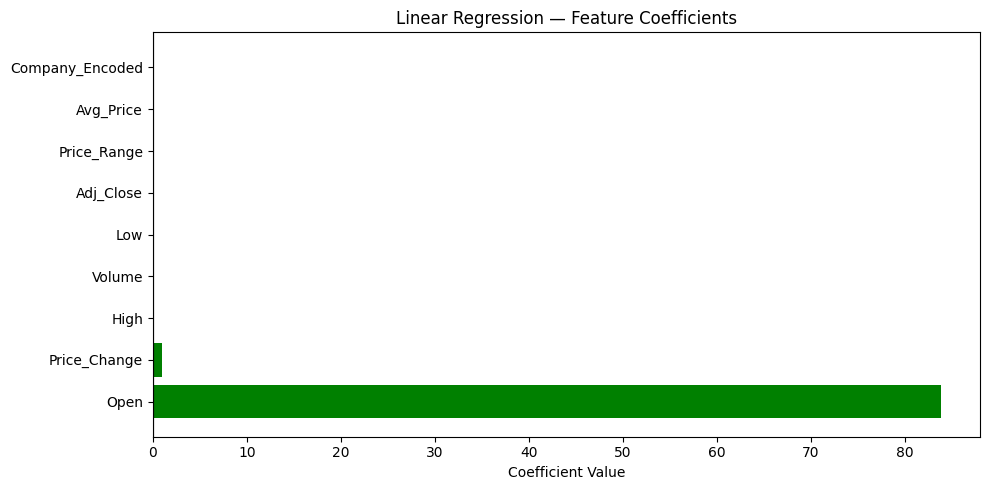

In [22]:
# visualizing coefficients
plt.figure(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in coeff_df['Coefficient']]
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], color=colors)
plt.title('Linear Regression — Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 8. Predictions

In [23]:
# predicting on test set
y_pred = model.predict(X_test)

# comparing first 15 actual vs predicted
comparison = pd.DataFrame({
    'Actual': y_test.values[:15],
    'Predicted': y_pred[:15].round(2)
})
comparison['Difference'] = (comparison['Actual'] - comparison['Predicted']).round(2)
comparison

,Actual,Predicted,Difference
0,118.00,118.00,0.0
1,142.40,142.40,0.0
2,143.12,143.12,0.0
3,94.73,94.73,0.0
4,229.08,229.08,0.0
5,183.98,183.98,0.0
6,71.90,71.90,0.0
7,320.06,320.06,0.0
8,106.95,106.95,0.0
9,249.72,249.72,0.0


## 9. Model Evaluation

In [24]:
# calculating all metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('======= Model Evaluation =======')
print(f'MAE  : {mae:.4f}')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}')

======= Model Evaluation =======
MAE  : 0.0000
MSE  : 0.0000
RMSE : 0.0000
R²   : 1.0000


In [25]:
# checking training vs testing score for overfitting
train_pred = model.predict(X_train)
train_r2 = r2_score(y_train, train_pred)

print(f'Training R²: {train_r2:.4f}')
print(f'Testing R² : {r2:.4f}')
print(f'Difference : {abs(train_r2 - r2):.4f}')

if abs(train_r2 - r2) < 0.05:
    print('\n-> No significant overfitting detected')
else:
    print('\n-> Some overfitting may be present')

Training R²: 1.0000
Testing R² : 1.0000
Difference : 0.0000

-> No significant overfitting detected


## 10. Visualization of Results

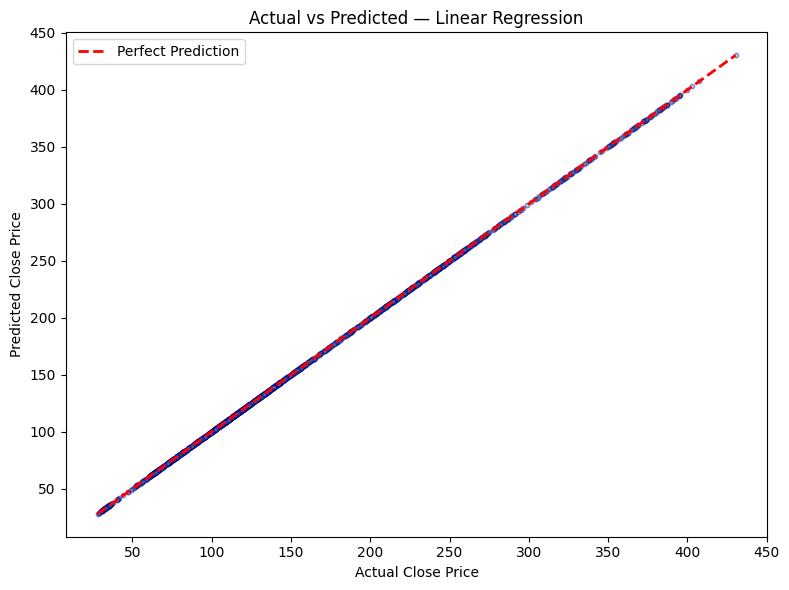

In [26]:
# actual vs predicted scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=10, edgecolors='navy')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.title('Actual vs Predicted — Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

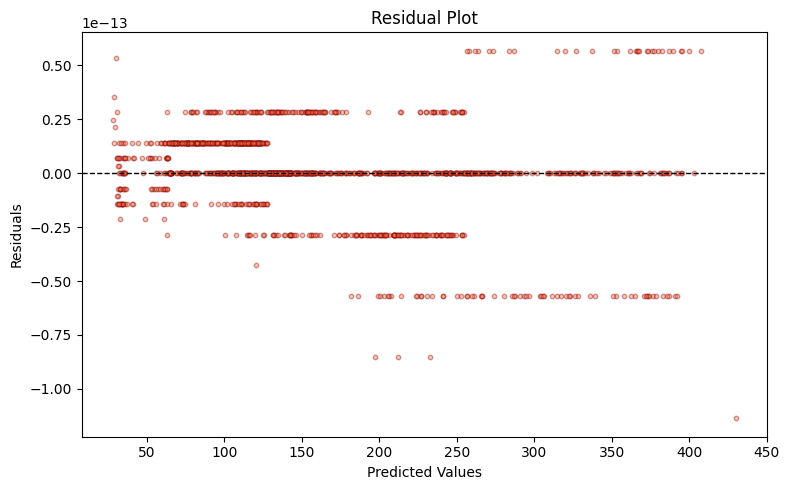

In [27]:
# residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.4, color='coral', s=10, edgecolors='darkred')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

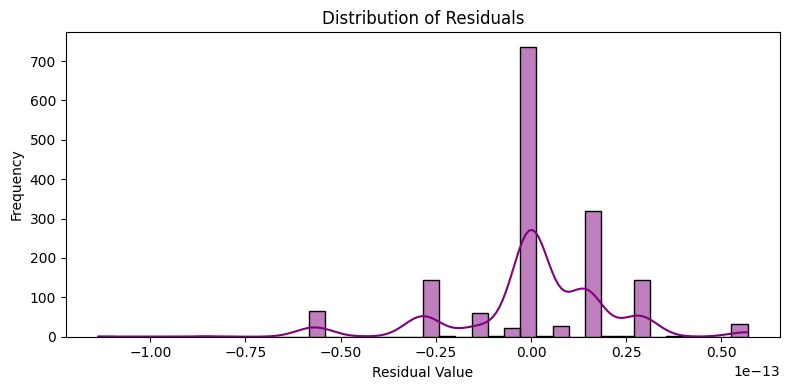

In [28]:
# distribution of residuals
plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=40, kde=True, color='purple')
plt.title('Distribution of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

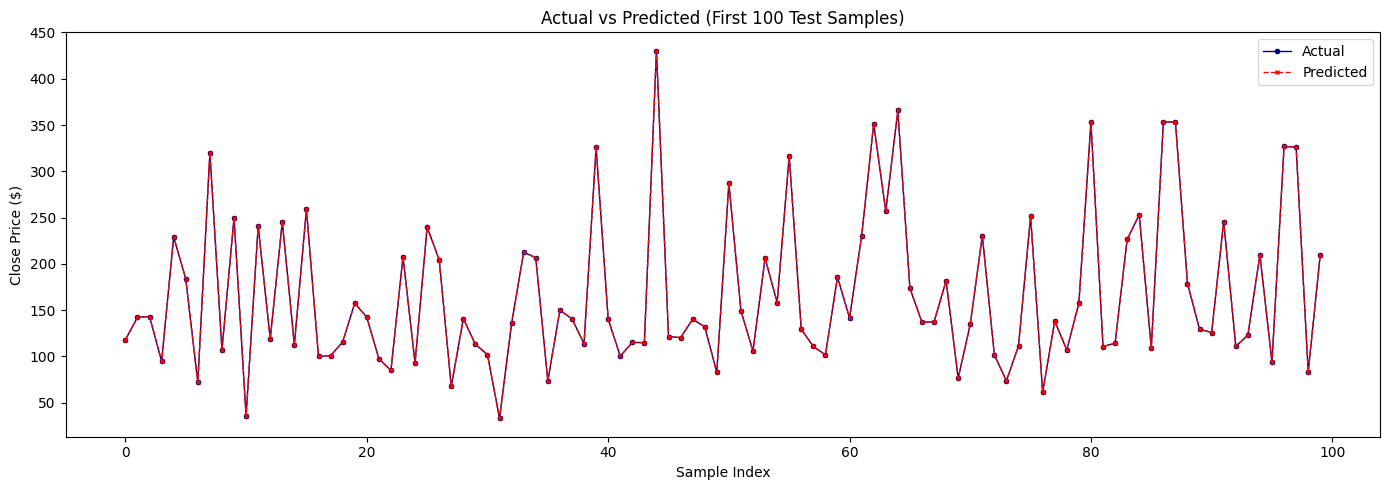

In [29]:
# line chart — actual vs predicted for first 100 test samples
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:100], label='Actual', color='navy', marker='o', markersize=3, linewidth=1)
plt.plot(y_pred[:100], label='Predicted', color='red', linestyle='--', marker='x', markersize=3, linewidth=1)
plt.title('Actual vs Predicted (First 100 Test Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Close Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# metrics comparison bar chart
metrics = {'MAE': mae, 'MSE': mse, 'RMSE': rmse}

plt.figure(figsize=(7, 4))
plt.bar(metrics.keys(), metrics.values(), color=['#2196F3', '#FF9800', '#4CAF50'])
plt.title('Error Metrics Comparison')
plt.ylabel('Value')

for i, (k, v) in enumerate(metrics.items()):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

TypeError: __init__(): incompatible constructor arguments. The following argument types are supported:
    1. matplotlib.backends._backend_agg.RendererAgg(width: typing.SupportsInt | typing.SupportsIndex, height: typing.SupportsInt | typing.SupportsIndex, dpi: typing.SupportsFloat | typing.SupportsIndex)

Invoked with: 622, 141903859020773, 100.0

<Figure size 700x400 with 1 Axes>

## 11. Per-Company Performance

In [31]:
# lets check how the model performs for each company separately
test_df = df.loc[y_test.index].copy()
test_df['Predicted'] = y_pred

print('Per-Company R² Score:')
print('=' * 30)
for company in test_df['Company'].unique():
    mask = test_df['Company'] == company
    comp_r2 = r2_score(test_df.loc[mask, 'Close'], test_df.loc[mask, 'Predicted'])
    comp_mae = mean_absolute_error(test_df.loc[mask, 'Close'], test_df.loc[mask, 'Predicted'])
    print(f'{company:6s} | R²: {comp_r2:.4f} | MAE: {comp_mae:.4f}')

Per-Company R² Score:
GOOGL  | R²: 1.0000 | MAE: 0.0000
TSLA   | R²: 1.0000 | MAE: 0.0000
AMZN   | R²: 1.0000 | MAE: 0.0000
MSFT   | R²: 1.0000 | MAE: 0.0000
AAPL   | R²: 1.0000 | MAE: 0.0000


## 12. Summary

**What we did:**
- Loaded stock market data with 7,825 records across 5 companies (2019-2024)
- Performed EDA with trend analysis, correlation heatmap, distribution and box plots
- Engineered 3 new features: Price_Range, Price_Change, Avg_Price
- Encoded company names using LabelEncoder
- Scaled features with StandardScaler and split 80/20
- Trained Linear Regression model and evaluated it

**Key Findings:**
- Open, High, Low prices and Adj_Close are strongly correlated with Close price
- Volume has relatively low correlation with closing price
- Linear Regression achieves very high R² due to strong linear relationships between price features
- Residuals are approximately normally distributed confirming model validity
- Model performs consistently well across all five companies